# HW04 — Симуляция распространения болезни по сети аэропортов

SI-модель распространения инфекции по авиамаршрутам США (2008). Стартовый аэропорт — **Allentown (ABE)**.

In [8]:
import kagglehub
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import random

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

path = kagglehub.dataset_download("vikalpdongre/us-flights-data-2008")
print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/2008.csv")
print(f"Размер датасета: {df.shape}")
df.head()

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\vikalpdongre\us-flights-data-2008\versions\1
Размер датасета: (7009728, 29)


,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,335,...,4.0,8.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,2008,1,3,4,754.0,735,1002.0,1000,WN,3231,...,5.0,10.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,2008,1,3,4,628.0,620,804.0,750,WN,448,...,3.0,17.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,2008,1,3,4,926.0,930,1054.0,1100,WN,1746,...,3.0,7.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,3920,...,3.0,10.0,0,NaN,0,2.0,0.0,0.0,0.0,32.0


In [9]:
# Предобработка: только выполненные рейсы, сортировка по времени вылета
df = df[df["Cancelled"] == 0].copy()

df["hour"] = df["CRSDepTime"] // 100
df["minute"] = df["CRSDepTime"] % 100
df["datetime"] = (
    pd.to_datetime(
        df[["Year", "Month", "DayofMonth"]].rename(
            columns={"Year": "year", "Month": "month", "DayofMonth": "day"}
        )
    )
    + pd.to_timedelta(df["hour"], unit="h")
    + pd.to_timedelta(df["minute"], unit="m")
)

df.sort_values("datetime", inplace=True)
df.reset_index(drop=True, inplace=True)

start_time = df["datetime"].iloc[0]
df["time_hours"] = (df["datetime"] - start_time).dt.total_seconds() / 3600.0

airports = sorted(set(df["Origin"].unique()) | set(df["Dest"].unique()))

# Allentown (ABE) — node_id = 0
if "ABE" in airports:
    airports.remove("ABE")
    airports.insert(0, "ABE")
else:
    print("Warning: ABE not found in dataset")

airport_to_id = {airport: i for i, airport in enumerate(airports)}
id_to_airport = {i: a for a, i in airport_to_id.items()}
start_airport = "ABE"
start_node = airport_to_id[start_airport]

n_airports = len(airports)
total_flights = len(df)

print(f"Аэропортов: {n_airports}, рейсов: {total_flights:,}")
print(f"Стартовый аэропорт: {start_airport} (node_id={start_node})")
print(f"Период: {df['datetime'].min()} — {df['datetime'].max()}")

Аэропортов: 305, рейсов: 6,872,294
Стартовый аэропорт: ABE (node_id=0)
Период: 2008-01-01 00:10:00 — 2008-12-31 23:59:00


## Часть 1. Симуляция распространения инфекции

In [10]:
def simulate_spread(flights_df, start_airport, p):
    """
    Один проход по датасету в хронологическом порядке
    """
    infected = {start_airport}
    infection_times = {start_airport: 0.0}

    for row in flights_df.itertuples():
        origin = row.Origin
        dest = row.Dest
        t = row.time_hours

        if origin in infected and dest not in infected:
            if random.random() < p:
                infected.add(dest)
                infection_times[dest] = t

    return infection_times


test_result = simulate_spread(df, start_airport, p=0.5)
print(f"Заражено аэропортов: {len(test_result)} из {n_airports}")
print("Примеры:", list(test_result.items())[:5])

Заражено аэропортов: 304 из 305
Примеры: [('ABE', 0.0), ('ORD', 7.166666666666667), ('PHX', 7.25), ('DTW', 7.25), ('IAH', 7.333333333333333)]


## Часть 2. Влияние вероятности заражения на скорость распространения

p=1.0: 100%|██████████| 10/10 [00:00<00:00, 229.33it/s]


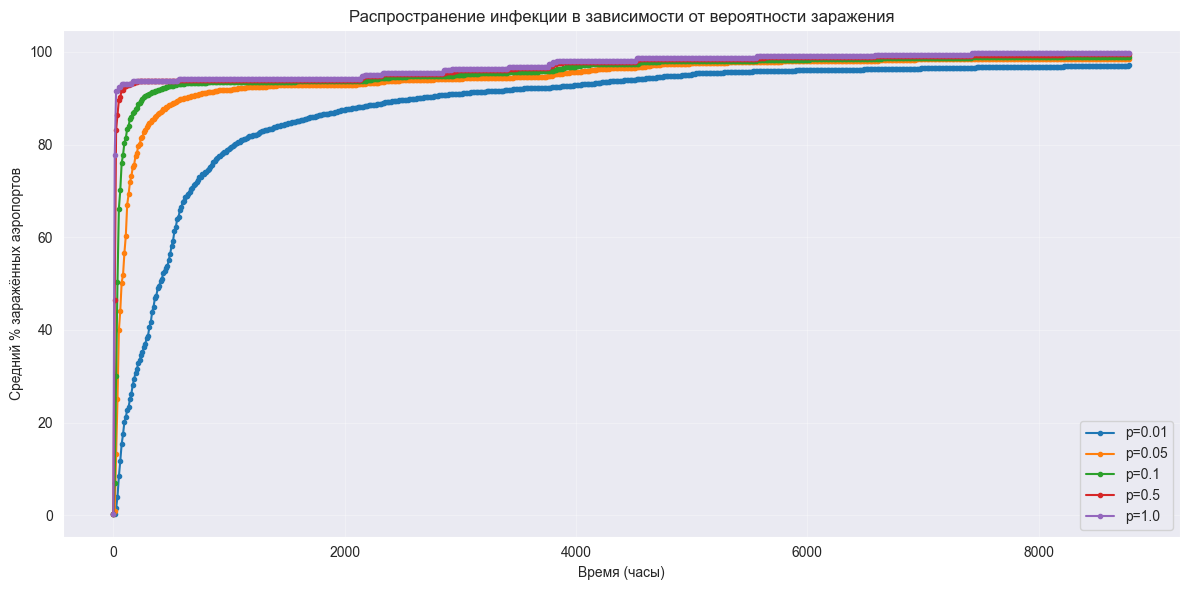

In [11]:
from numba import njit

# Ускоренная версия той же логики для множественных прогонов
airport_to_idx = {a: i for i, a in enumerate(airports)}
idx_to_airport = {i: a for a, i in airport_to_idx.items()}
origin_idx = df["Origin"].map(airport_to_idx).values.astype(np.int32)
dest_idx = df["Dest"].map(airport_to_idx).values.astype(np.int32)
time_arr = df["time_hours"].values.astype(np.float64)
start_idx = airport_to_idx[start_airport]


@njit
def simulate_spread_fast(origin_idx, dest_idx, times, start_idx, p, n_nodes):
    infection_times = np.full(n_nodes, -1.0)
    infection_times[start_idx] = 0.0

    for i in range(len(origin_idx)):
        o = origin_idx[i]
        d = dest_idx[i]
        t = times[i]
        if infection_times[o] >= 0.0 and infection_times[d] < 0.0:
            if np.random.random() < p:
                infection_times[d] = t
    return infection_times


def run_simulation(p):
    times = simulate_spread_fast(origin_idx, dest_idx, time_arr, start_idx, p, n_airports)
    return {idx_to_airport[i]: float(t) for i, t in enumerate(times) if t >= 0.0}


p_values = [0.01, 0.05, 0.1, 0.5, 1.0]
num_simulations = 10
time_bins = np.arange(0, time_arr.max() + 12, 12)

results_part2 = {}
for p in p_values:
    curves = []
    for _ in tqdm(range(num_simulations), desc=f"p={p}"):
        times = simulate_spread_fast(origin_idx, dest_idx, time_arr, start_idx, p, n_airports)
        times[times < 0] = np.inf
        curves.append(times)

    all_times = np.vstack(curves)
    avg_percentage = [(np.sum(all_times <= t) / (num_simulations * n_airports)) * 100 for t in time_bins]
    results_part2[p] = avg_percentage

plt.figure(figsize=(12, 6))
for p, avg_percentage in results_part2.items():
    plt.plot(time_bins, avg_percentage, marker="o", markersize=3, label=f"p={p}")

plt.xlabel("Время (часы)")
plt.ylabel("Средний % заражённых аэропортов")
plt.title("Распространение инфекции в зависимости от вероятности заражения")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Часть 3. Метрики графа и медианное время заражения

Граф: 305 вершин, 2827 рёбер


Part 3 simulations: 100%|██████████| 50/50 [00:00<00:00, 161.35it/s]
C:\Users\User\AppData\Local\Temp\ipykernel_20396\127697642.py:32: RuntimeWarning: All-NaN slice encountered
  median_infection_times = np.nanmedian(infection_matrix, axis=1)


Аэропортов с хотя бы одним заражением: 304 из 305


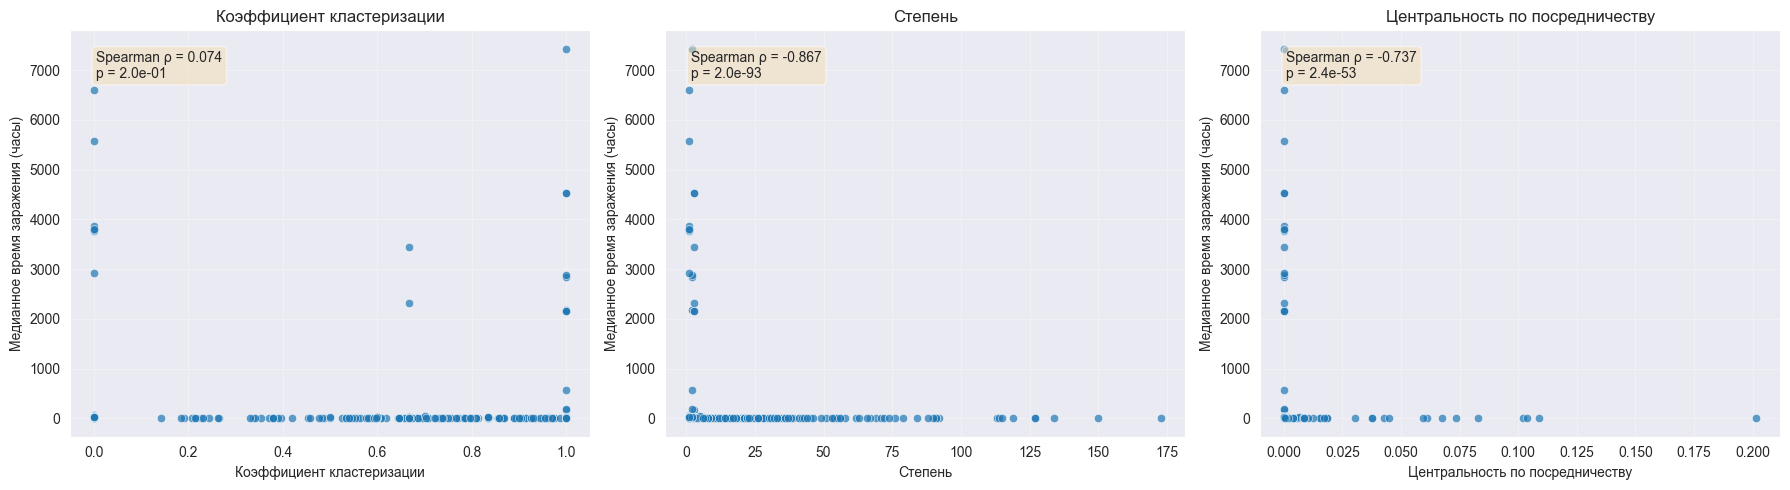

--- Коэффициент корреляции Спирмена ---
Коэффициент кластеризации: ρ = 0.0742, p-value = 1.97e-01
Степень: ρ = -0.8672, p-value = 1.96e-93
Центральность по посредничеству: ρ = -0.7372, p-value = 2.38e-53


In [12]:
# 3.1 Ненаправленный граф с весами = (рейсы A->B + B->A) / total_flights
edge_counts = {}
for row in df.itertuples():
    a, b = row.Origin, row.Dest
    if a > b:
        a, b = b, a
    edge_counts[(a, b)] = edge_counts.get((a, b), 0) + 1

G = nx.Graph()
for (a, b), cnt in edge_counts.items():
    G.add_edge(a, b, weight=cnt / total_flights)

print(f"Граф: {G.number_of_nodes()} вершин, {G.number_of_edges()} рёбер")

# 3.2 50 симуляций с p=0.5
p_sim = 0.5
num_sim_part3 = 50
all_infection_times = []

for _ in tqdm(range(num_sim_part3), desc="Part 3 simulations"):
    all_infection_times.append(run_simulation(p_sim))

# 3.3 Медианное время заражения каждого аэропорта
airport_list = list(airports)
infection_matrix = np.full((len(airport_list), num_sim_part3), np.nan)

for i, airport in enumerate(airport_list):
    for j, inf_dict in enumerate(all_infection_times):
        if airport in inf_dict:
            infection_matrix[i, j] = inf_dict[airport]

median_infection_times = np.nanmedian(infection_matrix, axis=1)
valid_mask = ~np.isnan(median_infection_times)
valid_airports = np.array(airport_list)[valid_mask]
median_times_valid = median_infection_times[valid_mask]

print(f"Аэропортов с хотя бы одним заражением: {valid_mask.sum()} из {n_airports}")

# 3.4 Метрики графа
clustering = nx.clustering(G)
degree = dict(G.degree())
betweenness = nx.betweenness_centrality(G)

metrics_df = pd.DataFrame({
    "airport": valid_airports,
    "median_time": median_times_valid,
    "clustering": [clustering[a] for a in valid_airports],
    "degree": [degree[a] for a in valid_airports],
    "betweenness": [betweenness[a] for a in valid_airports],
})

# 3.5 Scatter-plot и корреляция Спирмена
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_cols = ["clustering", "degree", "betweenness"]
titles = ["Коэффициент кластеризации", "Степень", "Центральность по посредничеству"]
spearman_results = {}

for ax, col, title in zip(axes, metric_cols, titles):
    sns.scatterplot(data=metrics_df, x=col, y="median_time", ax=ax, alpha=0.7)
    ax.set_xlabel(title)
    ax.set_ylabel("Медианное время заражения (часы)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    corr, pval = spearmanr(metrics_df[col], metrics_df["median_time"])
    spearman_results[col] = (corr, pval)
    ax.text(
        0.05,
        0.95,
        f"Spearman ρ = {corr:.3f}\np = {pval:.1e}",
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

plt.tight_layout()
plt.show()

print("--- Коэффициент корреляции Спирмена ---")
for col, title in zip(metric_cols, titles):
    corr, pval = spearman_results[col]
    print(f"{title}: ρ = {corr:.4f}, p-value = {pval:.2e}")

### Интерпретация результатов

 Чем выше вероятность заражения `p`, тем быстрее растёт доля заражённых аэропортов. При малых `p` (0.01–0.05) инфекция распространяется медленно и может не достичь всех узлов сети за месяц наблюдений. При `p = 1.0` каждый контакт с заражённым аэропортом гарантированно передаёт инфекцию, поэтому кривая растёт максимально быстро.

**Часть 3.** Медианное время заражения отражает, насколько «далеко» аэропорт находится от источника инфекции (Allentown) по цепочке авиарейсов.

- **Степень (degree)** — сильнее всего коррелирует с временем заражения (отрицательная корреляция): чем больше прямых связей у аэропорта, тем раньше он, как правило, заражается. Хабы с большим числом рейсов получают инфекцию быстрее.
- **Центральность по посредничеству** — также показывает отрицательную корреляцию: аэропорты на «кратчайших путях» между регионами заражаются раньше, так как через них проходит больше потоков.
- **Коэффициент кластеризации** — слабее связан с временем заражения: узлы в плотных локальных кластерах не обязательно находятся ближе к источнику инфекции.

**Вывод:** для предсказания порядка заражения в SI-модели на авиасети наиболее информативна **степень узла** — она лучше всего отражает интенсивность прямых контактов с уже заражёнными аэропортами.